### Supernova distances and redshifts (part 1)

Measuring the cosmological relationship between distance and redshift is at the heart of the entire field of cosmology and allowed, among other things, the discovery of dark energy! At high redshifts, this is done with Type Ia Supernova which are standard (or better, standardizable) candles.

Let's recall the definition of magnitude and the distance modulus

$$
\mu = m-M =  5 \log_{10}\left(\frac{d_L}{\rm pc}\right) - 5
$$

These are some supernova data

(35.0, 50.0)

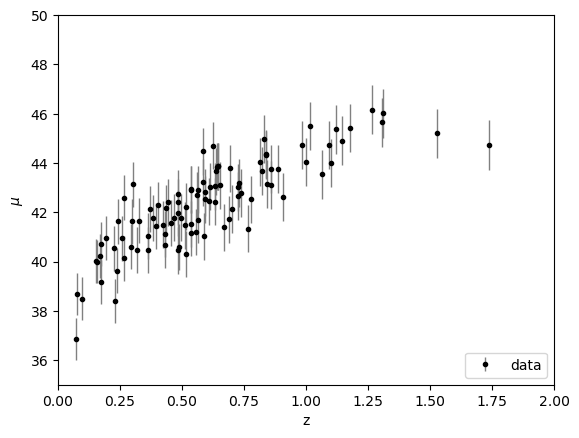

In [1]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

####  Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of  polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import learning_curve

c:\Users\aless\anaconda3\Lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


Let's star to fit the data by using linear regression:

Intercept =  39.60456481105869
Coefficient =  [4.5911933]


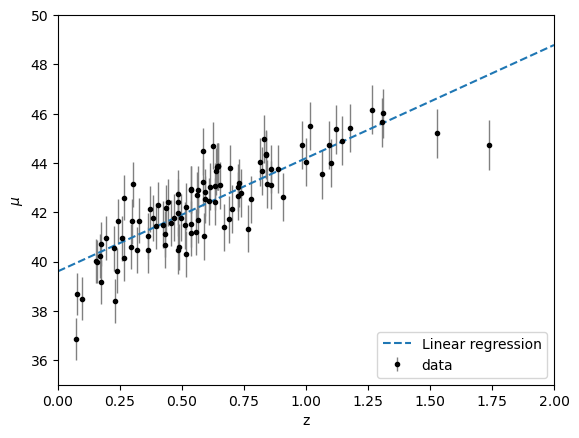

In [3]:
lin_reg = LinearRegression()
lin_reg.fit(z_sample[:, None], mu_sample, sample_weight=dmu)

z_grid = np.linspace(0, 2, 1000)
mu_pred = lin_reg.predict(z_grid[:, None])
theta_0 = lin_reg.intercept_
theta_1 = lin_reg.coef_

print('Intercept = ', theta_0)
print('Coefficient = ', theta_1)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.plot(z_grid, mu_pred, linestyle='--', label='Linear regression')
plt.legend(loc='lower right')

It seems like we are slightly undefitting the data. Let's look at what we get using a polynomial:

Polynomial degree 2 coefficients:  [38.44821027  8.49035585 -2.57760572]
Polynomial degree 3 coefficients:  [38.49130243  8.23905057 -2.20391808 -0.15168104]
Polynomial degree 4 coefficients:  [ 37.0543994   20.74217865 -32.83020744  27.30599762  -7.98337391]
Polynomial degree 5 coefficients:  [ 36.18760445  31.00142053 -69.82397489  82.84185044 -44.24104125
   8.47059008]


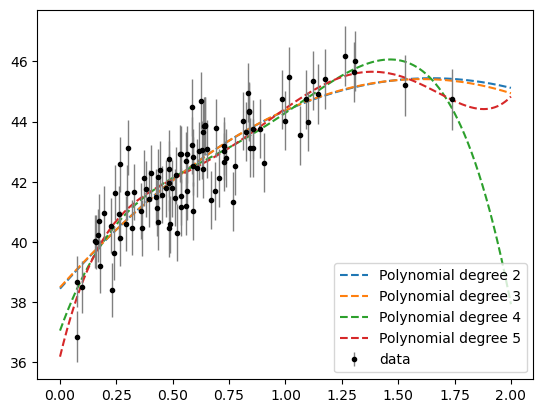

In [4]:
degrees = np.array([2, 3, 4, 5])

for deg in degrees:
    poly_reg = PolynomialRegression(degree=deg)
    poly_reg.fit(z_sample[:, None], mu_sample)
    mu_poly_pred = poly_reg.predict(z_grid[:, None])
    print(f'Polynomial degree {deg} coefficients: ', poly_reg.coef_)

    plt.plot(z_grid, mu_poly_pred, linestyle='--', label=f'Polynomial degree {deg}')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.legend(loc='lower right')

By eye it looks like that the best fits are the ones we obtain by polynomial regression using 2 or 3 degrees. For 5 degrees we are clearly ovefitting the data.

Let's check which one is the best fit by doing cross validation:

In [58]:
X_train, X_test, y_train, y_test = train_test_split(z_sample, mu_sample, test_size=0.3, train_size=0.7)

degrees = np.linspace(1, 10, 10, dtype=int)
param_grid = {'degree': degrees}

K = 5
poly_reg = PolynomialRegression()
grid_search = GridSearchCV(PolynomialRegression(), param_grid, cv=K, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train[:, None], y_train)
best_degree = grid_search.best_params_['degree']
best_model = grid_search.best_estimator_
print('Best degree from cross-validation: ', best_degree)

Best degree from cross-validation:  2


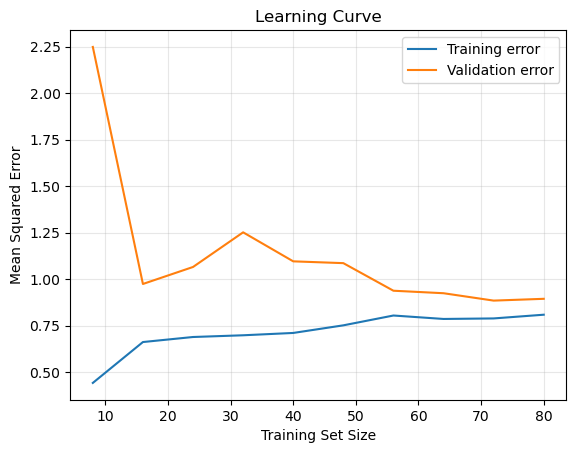

In [61]:
train_size_abs, train_scores, test_scores = learning_curve(best_model, z_sample[:,None], mu_sample,
                                                           train_sizes=np.linspace(0.1, 1.0, 10), 
                                                           cv=5, scoring='neg_mean_squared_error',
                                                           shuffle=True)

train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

plt.plot(train_size_abs, train_scores_mean, '-', label='Training error')
plt.plot(train_size_abs, test_scores_mean, '-', label='Validation error')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.grid(alpha = 0.3)

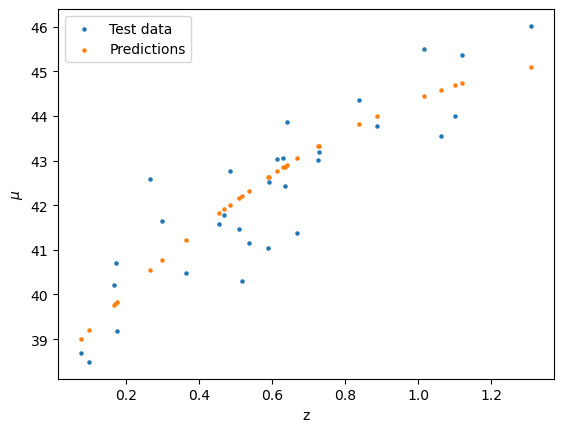

In [62]:
y_pred = best_model.predict(X_test[:, None])

plt.scatter(X_test, y_test, s=5, label='Test data')
plt.scatter(X_test, y_pred, s=5, label='Predictions')
plt.xlabel('z')
plt.ylabel('$\mu$')
plt.legend()